# Tutorial Round 1 Visualizations

This notebook plots the order book for **TOMATOES** and **EMERALDS** from the bot price snapshots.

- Bids are plotted in **blue**
- Asks are plotted in **red**

Data sources (Prosperity tutorial sample):
- `TUTORIAL_ROUND_1/prices_round_0_day_-2.csv` (bot day 1)
- `TUTORIAL_ROUND_1/prices_round_0_day_-1.csv` (bot day 2)


In [5]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [6]:
DATA_DIR = Path("TUTORIAL_ROUND_1")
DAY_1 = DATA_DIR / "prices_round_0_day_-2.csv"
DAY_2 = DATA_DIR / "prices_round_0_day_-1.csv"

assert DAY_1.exists(), f"Missing: {DAY_1}"
assert DAY_2.exists(), f"Missing: {DAY_2}"

df1 = pd.read_csv(DAY_1, sep=";")
df2 = pd.read_csv(DAY_2, sep=";")

# Stack both days for convenience; keep `day` to facet later.
df_all = pd.concat([df1, df2], ignore_index=True)
df_all[["day", "timestamp", "product"]].drop_duplicates().sort_values(["day", "timestamp", "product"]).head()

,day,timestamp,product
0,-2,0,EMERALDS
1,-2,0,TOMATOES
3,-2,100,EMERALDS
2,-2,100,TOMATOES
5,-2,200,EMERALDS


In [7]:
def book_side_long(df_in: pd.DataFrame, side: str) -> pd.DataFrame:
    # side in {"bid", "ask"}
    parts = []
    for level in (1, 2, 3):
        pcol = f"{side}_price_{level}"
        vcol = f"{side}_volume_{level}"
        if pcol not in df_in.columns or vcol not in df_in.columns:
            continue

        tmp = df_in[["day", "timestamp", "mid_price", pcol, vcol]].copy()
        tmp = tmp.rename(columns={pcol: "price", vcol: "volume"})
        tmp["level"] = level
        tmp["side"] = side
        parts.append(tmp)

    out = pd.concat(parts, ignore_index=True)
    out["price"] = pd.to_numeric(out["price"], errors="coerce")
    out["volume"] = pd.to_numeric(out["volume"], errors="coerce")
    out = out.dropna(subset=["price"])
    out["volume"] = out["volume"].fillna(0)
    out["abs_volume"] = out["volume"].abs()
    return out

def plot_order_book(product: str, df_prices: pd.DataFrame) -> None:
    dfp = df_prices[df_prices["product"] == product].copy()
    if dfp.empty:
        raise ValueError(f"No rows for product={product!r}")

    bids = book_side_long(dfp, "bid")
    asks = book_side_long(dfp, "ask")
    book = pd.concat([bids, asks], ignore_index=True)

    days = sorted(dfp["day"].unique())
    fig, axes = plt.subplots(len(days), 1, figsize=(14, 4 * len(days)), sharey=True)
    if len(days) == 1:
        axes = [axes]

    for ax, day in zip(axes, days):
        day_book = book[book["day"] == day]
        day_bids = day_book[day_book["side"] == "bid"]
        day_asks = day_book[day_book["side"] == "ask"]

        # Marker size scales with displayed volume.
        bid_sizes = 4 + 0.8 * day_bids["abs_volume"]
        ask_sizes = 4 + 0.8 * day_asks["abs_volume"]

        ax.scatter(day_bids["timestamp"], day_bids["price"], s=bid_sizes, c="blue", alpha=0.35, label="bids")
        ax.scatter(day_asks["timestamp"], day_asks["price"], s=ask_sizes, c="red", alpha=0.35, label="asks")

        mid = dfp[dfp["day"] == day].sort_values("timestamp")
        ax.plot(mid["timestamp"], mid["mid_price"], c="black", lw=1.0, alpha=0.9, label="mid")

        # Map day values to the more intuitive bot-day labels.
        bot_day = {-2: 1, -1: 2}.get(int(day), int(day))
        ax.set_title(f"{product} Order Book (bot day {bot_day}, raw day={day})")
        ax.set_xlabel("timestamp")
        ax.set_ylabel("price")
        ax.grid(True, alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.tight_layout()
    plt.show()

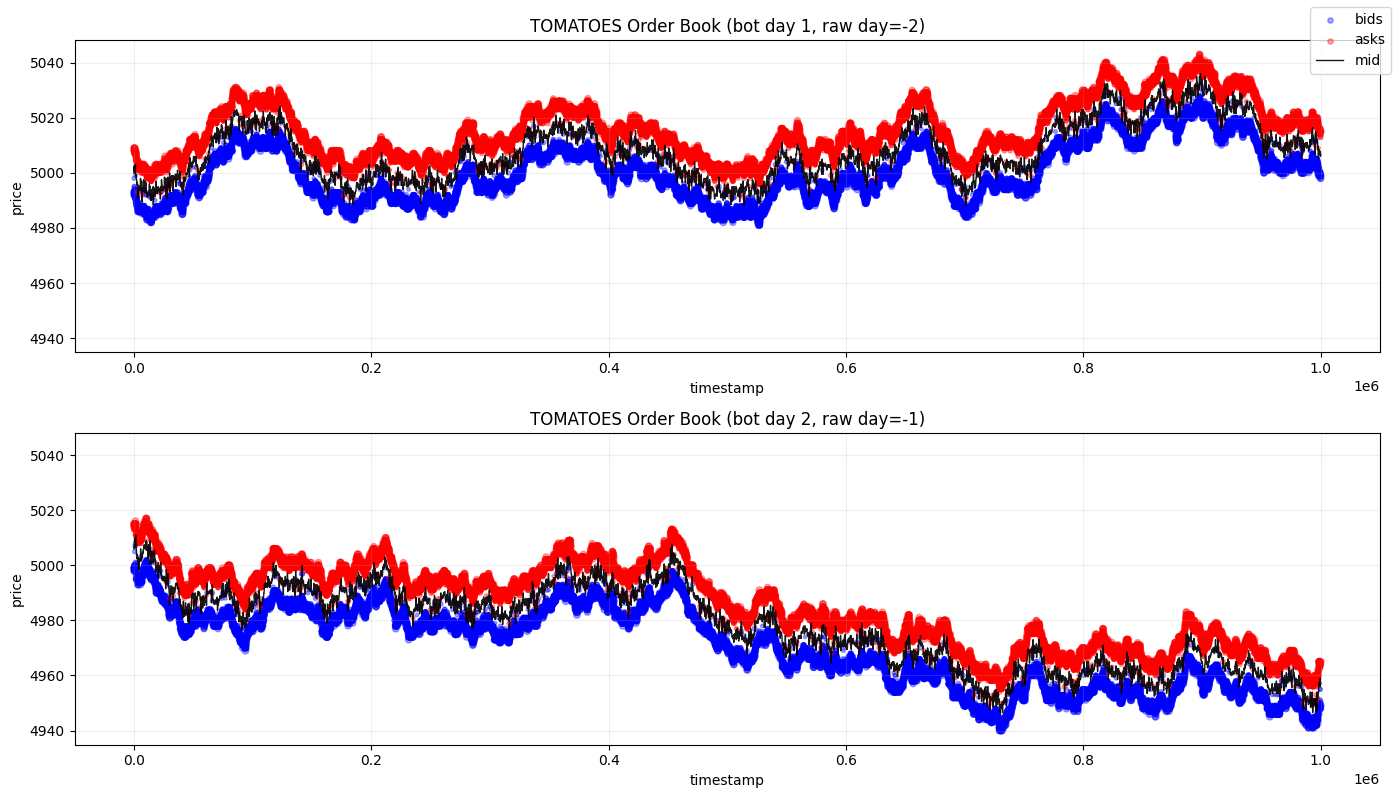

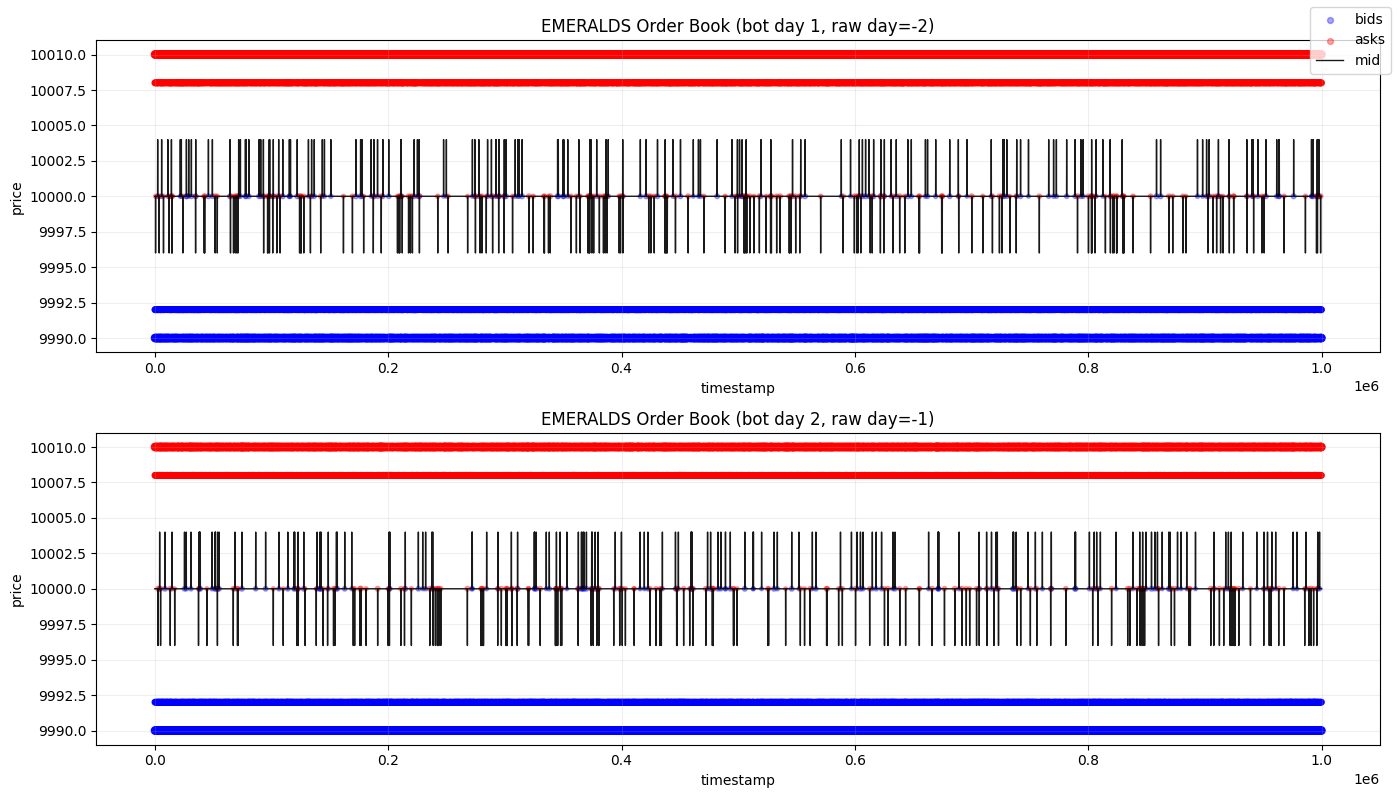

In [8]:
plot_order_book("TOMATOES", df_all)
plot_order_book("EMERALDS", df_all)